In [1]:
# https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
import torch
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix

# Load CIFAR10
train_data = datasets.CIFAR10(root="data", train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.CIFAR10(root="data", train=False, download=True, transform=transforms.ToTensor())
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)
# Set device to 'cuda' if available, otherwise 'cpu'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(train_data.data.shape)
for X,y in test_loader:
    print(f"shape of X : {X.shape}")
    print(f"shape of y : {y.shape} {y.dtype}")
    break

# Define MLP
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*32*3, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.layers(x)

model = MLP().to(device)
print(model)
print(model.parameters())
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)


def train(dataloader, model, loss_fun, optimizer):
    # training the model
    size = len(dataloader.dataset)
    model.train()
    for batch, (X,y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        pred = model(X)
        pred_prob = nn.Softmax(dim=1)(pred)
        loss = loss_fn(pred,y)

        #Backprop
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f} [{current:>5d}/{size:>5d}]")

def test(dataloader, model, loss_fun):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            pred_prob = nn.Softmax(dim=1)(pred)
            test_loss += loss_fun(pred_prob, y).item()
            correct += (pred_prob.argmax(1)==y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:8f} \n")

/home/user/code/nets/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Using device: cpu
(50000, 32, 32, 3)
shape of X : torch.Size([64, 3, 32, 32])
shape of y : torch.Size([64]) torch.int64
MLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)
<generator object Module.parameters at 0x7f196194d9a0>
Model structure: MLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)


Layer: layers.1.weight | Size: torch.Size([64, 3072]) | Values : tensor([[ 0.0174, -0.0116, -0.0128,  ..., -0.0118,  0.0107, -0.0024],
        [-0.0033, -0.0102, -0.0120,  ..., -0.0012,  0.0026, -0.0006]],
       grad_fn=<SliceBackward0>) 

Layer: layers.1.bias | Size: torch.Size([64]) | Values : tensor([-0.0121, -0.0091], grad_fn=<SliceBackward0>) 

Layer: layers.3.weight 

In [2]:
# calculating the mean and variance for normalization
raw_data = train_data.data
raw_data.shape
mean = raw_data.mean(axis=(0,1,2)) / 255.
std = raw_data.std(axis=(0, 1, 2)) / 255.
std

array([0.24703223, 0.24348513, 0.26158784])

In [3]:
# normalizing tranformation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, 
                         std=std)
])

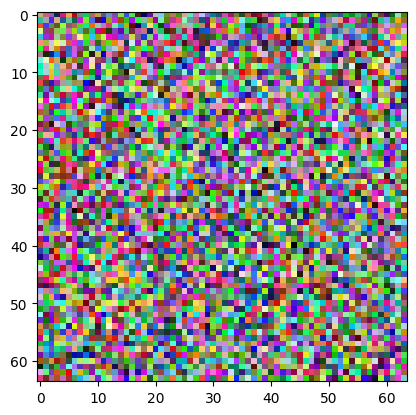

In [3]:
# noise test image
test_image = torch.rand(1,3,64,64)
test_image_np = test_image.squeeze(0).permute(1,2,0).numpy()
plt.imshow(test_image_np)

Text(0.5, 1.0, 'automobile')

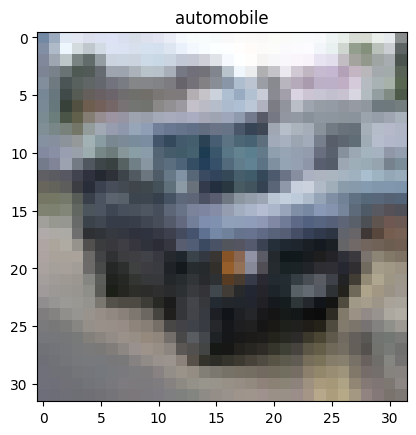

In [4]:
# data test image 
labels_map = train_data.classes
index = torch.randint(len(train_data), size=(1,)).item()
example_image, label = train_data[index]
# changing indices to fit imshow
example_image_permuted = example_image.squeeze(0).permute(1,2,0).numpy()
plt.imshow(example_image_permuted)
plt.title(labels_map[label])

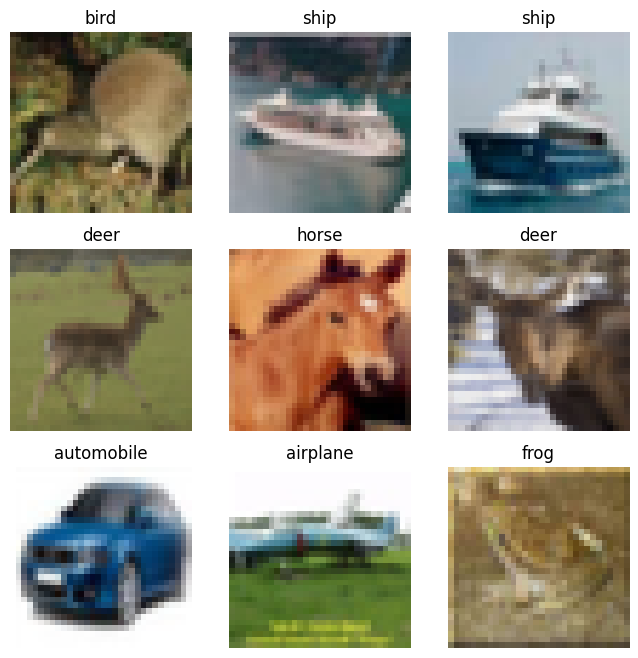

In [45]:
labels_map = train_data.classes
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(0).permute(1,2,0))
plt.show()

In [79]:
X = test_loader
X.dataset.data.shape

(10000, 32, 32, 3)

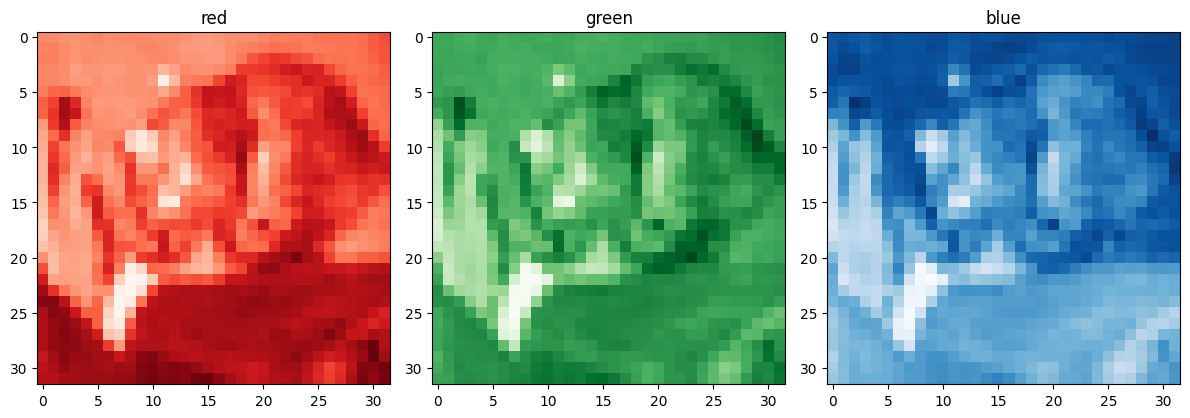

In [39]:
# data loader swaps indices 
# plot (R,G,B) channels
titles = ["red","green","blue"]
maps = ["Reds_r","Greens_r","Blues_r"]
img = X.dataset.data[0]
fig, ax = plt.subplots(1,3,figsize=(12,4))
for i in range(3):
    ax[i].imshow(img[:,:,i],cmap=maps[i])
    ax[i].set_title(titles[i])
plt.tight_layout()



In [46]:
epochs = 30

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_loader, model, loss_fn, optimizer)
    test(test_loader, model, loss_fn)
print("Done")

Epoch 1
-------------------------------
loss: 2.093790 [   64/50000]
loss: 2.144302 [ 6464/50000]
loss: 2.119349 [12864/50000]
loss: 2.059993 [19264/50000]
loss: 2.097576 [25664/50000]
loss: 2.092294 [32064/50000]
loss: 2.136244 [38464/50000]
loss: 2.050634 [44864/50000]
test Error: 
 Accuracy: 29.9%, Avg loss: 2.267147 

Epoch 2
-------------------------------
loss: 1.997321 [   64/50000]
loss: 1.992844 [ 6464/50000]
loss: 2.119686 [12864/50000]
loss: 2.076097 [19264/50000]
loss: 2.072056 [25664/50000]
loss: 2.065160 [32064/50000]
loss: 2.023402 [38464/50000]
loss: 1.993947 [44864/50000]
test Error: 
 Accuracy: 30.9%, Avg loss: 2.255368 

Epoch 3
-------------------------------
loss: 2.047162 [   64/50000]
loss: 2.132204 [ 6464/50000]
loss: 2.022123 [12864/50000]
loss: 2.004631 [19264/50000]
loss: 1.944696 [25664/50000]
loss: 1.917429 [32064/50000]
loss: 1.938676 [38464/50000]
loss: 2.033342 [44864/50000]
test Error: 
 Accuracy: 31.6%, Avg loss: 2.245038 

Epoch 4
--------------------

In [ ]:
# normalizing tranformation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, 
                         std=std)
])

In [88]:
# trying normalized
train_data = datasets.CIFAR10(root="data", train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(root="data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

/home/user/code/nets/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9892129..2.0784714].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6742239..2.1267893].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9574634..0.56661797].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8939645..1.8759435].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7669667..2.1267893].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7828414..2.1267893].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.64703

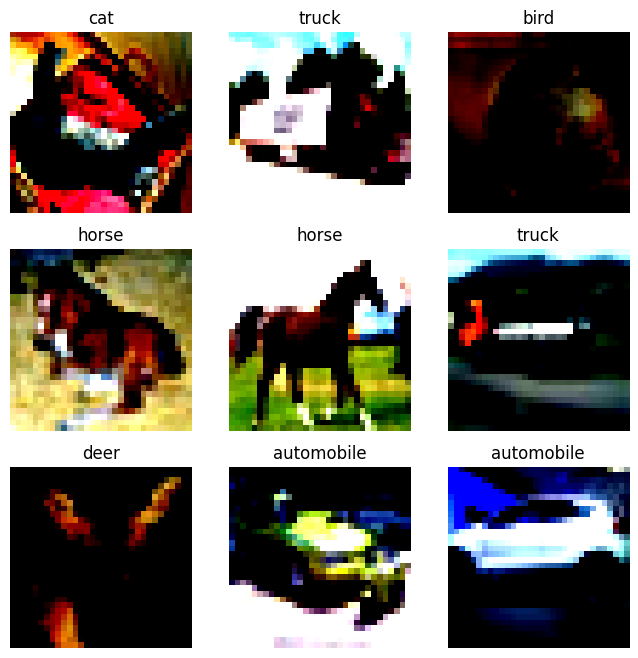

In [90]:
labels_map = train_data.classes
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(0).permute(1,2,0),cmap='gray')
plt.show()

In [91]:
epochs = 10

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_loader, model, loss_fn, optimizer)
    test(test_loader, model, loss_fn)
print("Done")

Epoch 1
-------------------------------
loss: 2.645513 [   64/50000]
loss: 1.907994 [ 6464/50000]
loss: 1.557801 [12864/50000]
loss: 1.795321 [19264/50000]
loss: 1.963064 [25664/50000]
loss: 1.684578 [32064/50000]
loss: 1.646545 [38464/50000]
loss: 1.795583 [44864/50000]
test Error: 
 Accuracy: 41.3%, Avg loss: 2.116934 

Epoch 2
-------------------------------
loss: 1.557063 [   64/50000]
loss: 1.636783 [ 6464/50000]
loss: 2.093339 [12864/50000]
loss: 1.626561 [19264/50000]
loss: 1.715531 [25664/50000]
loss: 1.554304 [32064/50000]
loss: 1.623916 [38464/50000]
loss: 1.554583 [44864/50000]
test Error: 
 Accuracy: 42.6%, Avg loss: 2.120114 

Epoch 3
-------------------------------
loss: 1.671252 [   64/50000]
loss: 1.590092 [ 6464/50000]
loss: 1.616989 [12864/50000]
loss: 1.788162 [19264/50000]
loss: 1.430741 [25664/50000]
loss: 1.590109 [32064/50000]
loss: 1.765132 [38464/50000]
loss: 1.713576 [44864/50000]
test Error: 
 Accuracy: 43.5%, Avg loss: 2.122087 

Epoch 4
--------------------

Decent jump in accuracy out the gate from normalization. Test with gradient momentum.

In [92]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3,momentum=0.9)

In [ ]:
epochs = 5

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_loader, model, loss_fn, optimizer)
    test(test_loader, model, loss_fn)
print("Done")

Epoch 1
-------------------------------
loss: 1.507872 [   64/50000]
loss: 1.675355 [ 6464/50000]
loss: 1.552860 [12864/50000]
loss: 1.603224 [19264/50000]
loss: 1.396042 [25664/50000]
loss: 1.830203 [32064/50000]
loss: 1.536492 [38464/50000]
loss: 1.478734 [44864/50000]
test Error: 
 Accuracy: 46.5%, Avg loss: 2.091105 

Epoch 2
-------------------------------
loss: 1.509683 [   64/50000]
loss: 1.536500 [ 6464/50000]
loss: 1.684322 [12864/50000]
loss: 1.724014 [19264/50000]
loss: 1.555864 [25664/50000]
loss: 1.563134 [32064/50000]


# Datsets and Dataloaders

In [2]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

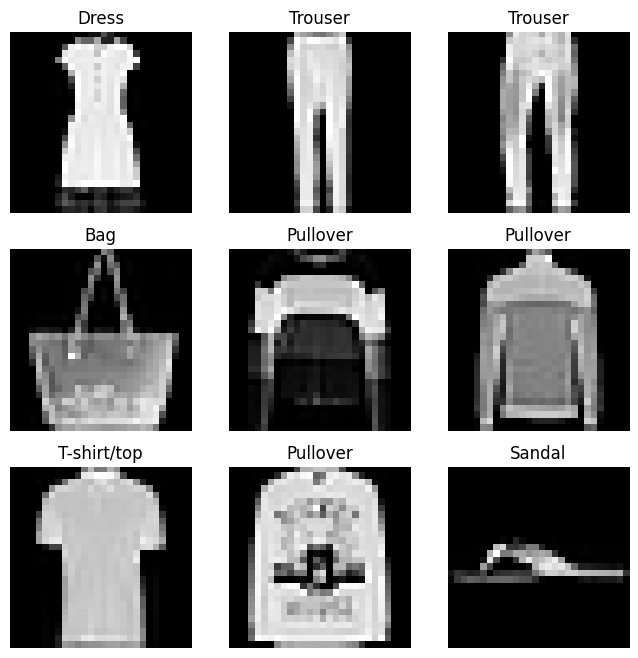

In [4]:


labels_map = test_data.classes

figure = plt.figure(figsize=(8,8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_index = torch.randint(len(training_data),size=(1,)).item()
    img, label = training_data[sample_index]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(),cmap="gray")

# Custom Dataset
Needs `__init__`, `__len__` and `__getitem__` functions. For fashion MNIST the labels are stored in `.csv` and the images are in 

In [5]:
import os 
import pandas as pd 
from torchvision.io import decode_image
from torch.utils.data import Dataset

class CustomDataset(Dataset):
    def __init__(self,annotations_file, img_dir, transform=None,
                 target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform
    def __len__(self):
        return len(self.img_labels)
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

`DataLoader` allows for processing the data into batches

In [6]:
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data,batch_size=64,shuffle=True)

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])
label: 9


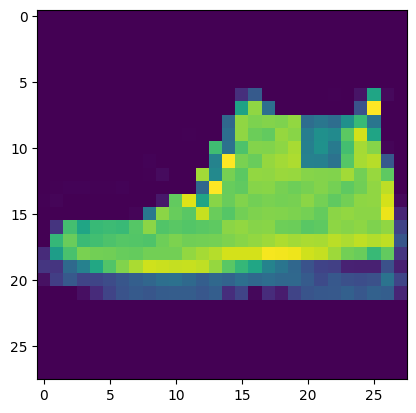

In [9]:
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img)
print(f"label: {label}")